#  Compute the linearized response matrix A and A+

Goal:
1. Load the calibrated operating point from Notebook 1.
2. Rebuild the NV Hamiltonian at the fitted operating point.
3. Linearize the four tracked ODMR transition frequencies with respect to small field changes.
4. Compute the 4x3 matrix A and its Moore–Penrose pseudoinverse A+.
5. Check numerical stability and round-trip reconstruction.

Convention used here:
- Common reconstruction frame = the same crystal-attached frame used in Notebook 1.
- Tracked resonances = the four lower-frequency transitions [d1, d2, d3, d4].
- D and Mz are held fixed while differentiating with respect to B.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
results_df = pd.read_csv("results.csv")
display(results_df.head(20))


,group,name,value
0,operating_point,Bx0_mT,0.431051
1,operating_point,By0_mT,3.103259
2,operating_point,Bz0_mT,0.360538
3,operating_point,B0_norm_mT,3.153729
4,operating_point,D_fit_MHz,2867.204880
5,operating_point,Mz_d1_MHz,-0.116911
6,operating_point,Mz_d2_MHz,-0.015133
7,operating_point,Mz_d3_MHz,-0.197859
8,operating_point,Mz_d4_MHz,-0.097547
9,operating_point,fit_residual_norm_MHz,0.130536


In [3]:
# Operating point from Notebook 1
Bx0 = float(results_df.loc[results_df["name"] == "Bx0_mT", "value"].iloc[0])
By0 = float(results_df.loc[results_df["name"] == "By0_mT", "value"].iloc[0])
Bz0 = float(results_df.loc[results_df["name"] == "Bz0_mT", "value"].iloc[0])

D_fit_mhz = float(results_df.loc[results_df["name"] == "D_fit_MHz", "value"].iloc[0])

Mz_d1 = float(results_df.loc[results_df["name"] == "Mz_d1_MHz", "value"].iloc[0])
Mz_d2 = float(results_df.loc[results_df["name"] == "Mz_d2_MHz", "value"].iloc[0])
Mz_d3 = float(results_df.loc[results_df["name"] == "Mz_d3_MHz", "value"].iloc[0])
Mz_d4 = float(results_df.loc[results_df["name"] == "Mz_d4_MHz", "value"].iloc[0])

B0 = np.array([Bx0, By0, Bz0], dtype=float)
Mz_map = {
    "d1": Mz_d1,
    "d2": Mz_d2,
    "d3": Mz_d3,
    "d4": Mz_d4,
}

print("Loaded operating point:")
print("B0 [mT] =", B0)
print("|B0| [mT] =", np.linalg.norm(B0))
print("D [MHz] =", D_fit_mhz)
print("Mz map [MHz] =", Mz_map)

Loaded operating point:
B0 [mT] = [0.4310514  3.10325887 0.36053808]
|B0| [mT] = 3.1537293177674357
D [MHz] = 2867.2048796380577
Mz map [MHz] = {'d1': -0.1169110429075156, 'd2': -0.0151330664031085, 'd3': -0.1978591246391141, 'd4': -0.0975468272101976}


In [4]:
f_left_meas = np.array([
    float(results_df.loc[results_df["name"] == "d1_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d2_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d3_f_left_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d4_f_left_meas_MHz", "value"].iloc[0]),
], dtype=float)

f_right_meas = np.array([
    float(results_df.loc[results_df["name"] == "d1_f_right_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d2_f_right_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d3_f_right_meas_MHz", "value"].iloc[0]),
    float(results_df.loc[results_df["name"] == "d4_f_right_meas_MHz", "value"].iloc[0]),
], dtype=float)

axes_order = ["d1", "d2", "d3", "d4"]

print("Measured lower tracked frequencies [MHz]:", f_left_meas)
print("Measured upper frequencies [MHz]:", f_right_meas)


Measured lower tracked frequencies [MHz]: [2791.20577148 2803.93502334 2855.26217136 2866.88305566]
Measured upper frequencies [MHz]: [2944.96621989 2934.17350762 2886.66093768 2875.48057627]


## add constrains and spin matrices+ local frames for each NV axis


In [6]:
GAMMA_E_MHZ_PER_MT = 28.02495164

Sx = (1 / np.sqrt(2)) * np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
], dtype=float)

Sy = (1 / np.sqrt(2)) * np.array([
    [0, -1j, 0],
    [1j, 0, -1j],
    [0, 1j, 0]
], dtype=complex)

Sz = np.array([
    [1, 0, 0],
    [0, 0, 0],
    [0, 0, -1]
], dtype=float)

Sz2 = Sz @ Sz

SQRT2_OVER3 = np.sqrt(2.0 / 3.0)
ONE_OVER_SQRT3 = 1.0 / np.sqrt(3.0)

n_d3 = np.array([ SQRT2_OVER3,  0.0,             ONE_OVER_SQRT3])
n_d2 = np.array([ 0.0,           SQRT2_OVER3,   -ONE_OVER_SQRT3])
n_d4 = np.array([-SQRT2_OVER3,   0.0,             ONE_OVER_SQRT3])
n_d1 = np.array([ 0.0,          -SQRT2_OVER3,   -ONE_OVER_SQRT3])

NV_AXES = {
    "d1": n_d1,
    "d2": n_d2,
    "d3": n_d3,
    "d4": n_d4,
}

for k, v in NV_AXES.items():
    print(k, v, "norm =", np.linalg.norm(v))



LOCAL_FRAMES = {}

for axis, n in NV_AXES.items():
    ez = n / np.linalg.norm(n)

    ref = np.array([0.0, 0.0, 1.0])
    if np.abs(np.dot(ref, ez)) > 0.9:
        ref = np.array([1.0, 0.0, 0.0])

    ex = np.cross(ref, ez)
    ex = ex / np.linalg.norm(ex)

    ey = np.cross(ez, ex)
    ey = ey / np.linalg.norm(ey)

    LOCAL_FRAMES[axis] = {"ex": ex, "ey": ey, "ez": ez}

LOCAL_FRAMES

#sanity check
for axis in axes_order:
    ex = LOCAL_FRAMES[axis]["ex"]
    ey = LOCAL_FRAMES[axis]["ey"]
    ez = LOCAL_FRAMES[axis]["ez"]

    M = np.vstack([ex, ey, ez])
    print(axis)
    print(np.round(M @ M.T, 6))
    print()


d1 [ 0.         -0.81649658 -0.57735027] norm = 1.0
d2 [ 0.          0.81649658 -0.57735027] norm = 1.0
d3 [0.81649658 0.         0.57735027] norm = 1.0
d4 [-0.81649658  0.          0.57735027] norm = 1.0
d1
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

d2
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

d3
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

d4
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]



In [7]:
f_left_pred = []
f_right_pred = []

for axis in axes_order:
    ex = LOCAL_FRAMES[axis]["ex"]
    ey = LOCAL_FRAMES[axis]["ey"]
    ez = LOCAL_FRAMES[axis]["ez"]

    Bx_loc = np.dot(B0, ex)
    By_loc = np.dot(B0, ey)
    Bz_loc = np.dot(B0, ez)

    H = (D_fit_mhz + Mz_map[axis]) * Sz2 + GAMMA_E_MHZ_PER_MT * (Bx_loc * Sx + By_loc * Sy + Bz_loc * Sz)

    evals = np.linalg.eigvalsh(H)
    evals = np.sort(np.real(evals))

    f_left_pred.append(evals[1] - evals[0])
    f_right_pred.append(evals[2] - evals[0])

f_left_pred = np.array(f_left_pred, dtype=float)
f_right_pred = np.array(f_right_pred, dtype=float)

compare_op_df = pd.DataFrame({
    "axis": axes_order,
    "f_left_meas_MHz": f_left_meas,
    "f_left_pred_MHz": f_left_pred,
    "left_err_kHz": 1e3 * (f_left_pred - f_left_meas),
    "f_right_meas_MHz": f_right_meas,
    "f_right_pred_MHz": f_right_pred,
    "right_err_kHz": 1e3 * (f_right_pred - f_right_meas),
})
display(compare_op_df)


,axis,f_left_meas_MHz,f_left_pred_MHz,left_err_kHz,f_right_meas_MHz,f_right_pred_MHz,right_err_kHz
0,d1,2791.205771,2791.250978,45.206789,2944.966220,2944.921015,-45.205316
1,d2,2803.935023,2803.889379,-45.644813,2934.173508,2934.219153,45.644922
2,d3,2855.262171,2855.216471,-45.700005,2886.660938,2886.706641,45.702898
3,d4,2866.883056,2866.931049,47.993500,2875.480576,2875.432567,-48.009539


In [8]:
# Central-difference field step for numerical linearization
# Units: mT
dB_step_mT = 1e-3   # 1 microtesla

print("Using central-difference step dB =", dB_step_mT, "mT")

Using central-difference step dB = 0.001 mT


In [9]:
A = np.zeros((4, 3), dtype=float)

unit_vectors = np.eye(3)

for j in range(3):
    B_plus = B0 + dB_step_mT * unit_vectors[j]
    B_minus = B0 - dB_step_mT * unit_vectors[j]

    f_left_plus = []
    f_left_minus = []

    for axis in axes_order:
        ex = LOCAL_FRAMES[axis]["ex"]
        ey = LOCAL_FRAMES[axis]["ey"]
        ez = LOCAL_FRAMES[axis]["ez"]

        # B_plus
        Bx_loc_p = np.dot(B_plus, ex)
        By_loc_p = np.dot(B_plus, ey)
        Bz_loc_p = np.dot(B_plus, ez)
        H_plus = (D_fit_mhz + Mz_map[axis]) * Sz2 + GAMMA_E_MHZ_PER_MT * (Bx_loc_p * Sx + By_loc_p * Sy + Bz_loc_p * Sz)
        evals_plus = np.sort(np.real(np.linalg.eigvalsh(H_plus)))
        f_left_plus.append(evals_plus[1] - evals_plus[0])

        # B_minus
        Bx_loc_m = np.dot(B_minus, ex)
        By_loc_m = np.dot(B_minus, ey)
        Bz_loc_m = np.dot(B_minus, ez)
        H_minus = (D_fit_mhz + Mz_map[axis]) * Sz2 + GAMMA_E_MHZ_PER_MT * (Bx_loc_m * Sx + By_loc_m * Sy + Bz_loc_m * Sz)
        evals_minus = np.sort(np.real(np.linalg.eigvalsh(H_minus)))
        f_left_minus.append(evals_minus[1] - evals_minus[0])

    f_left_plus = np.array(f_left_plus, dtype=float)
    f_left_minus = np.array(f_left_minus, dtype=float)

    A[:, j] = (f_left_plus - f_left_minus) / (2.0 * dB_step_mT)

A_df = pd.DataFrame(A, index=axes_order, columns=["dnu_dBx", "dnu_dBy", "dnu_dBz"])
display(A_df)

,dnu_dBx,dnu_dBy,dnu_dBz
d1,0.356984,-22.163057,-17.190345
d2,0.355660,-21.881868,17.580840
d3,-22.812125,2.479327,-16.086076
d4,-21.442501,2.275476,15.650009


In [10]:
A_plus = np.linalg.pinv(A)

A_plus_df = pd.DataFrame(
    A_plus,
    index=["Bx_recon", "By_recon", "Bz_recon"],
    columns=[f"dnu_{ax}" for ax in axes_order]
)

display(A_plus_df)

,dnu_d1,dnu_d2,dnu_d3,dnu_d4
Bx_recon,-0.001968,-0.002926,-0.022872,-0.022384
By_recon,-0.022954,-0.022530,-0.000408,-0.000322
Bz_recon,-0.015620,0.015784,-0.013867,0.014755


Singular values of A: [33.6710605  32.82679422 29.30374913]
Condition number of A: 1.1490359255663398


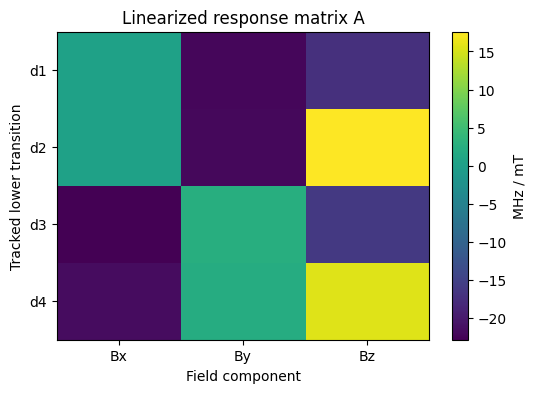

In [12]:
#inspect single values
U, svals, VT = np.linalg.svd(A, full_matrices=False)
cond_A = svals.max() / svals.min()

print("Singular values of A:", svals)
print("Condition number of A:", cond_A)

plt.figure(figsize=(6, 4))
plt.imshow(A, aspect="auto")
plt.colorbar(label="MHz / mT")
plt.xticks([0, 1, 2], ["Bx", "By", "Bz"])
plt.yticks(range(4), axes_order)
plt.title("Linearized response matrix A")
plt.xlabel("Field component")
plt.ylabel("Tracked lower transition")
plt.show()

## Stability test, small change how does A change?

,step_mT,max_rel_change_A_vs_ref,max_rel_change_Aplus_vs_ref
0,0.0001,0.000001,0.000006
1,0.0003,0.000001,0.000005
2,0.0010,0.000000,0.000000
3,0.0030,0.000012,0.000045
4,0.0100,0.000145,0.000559


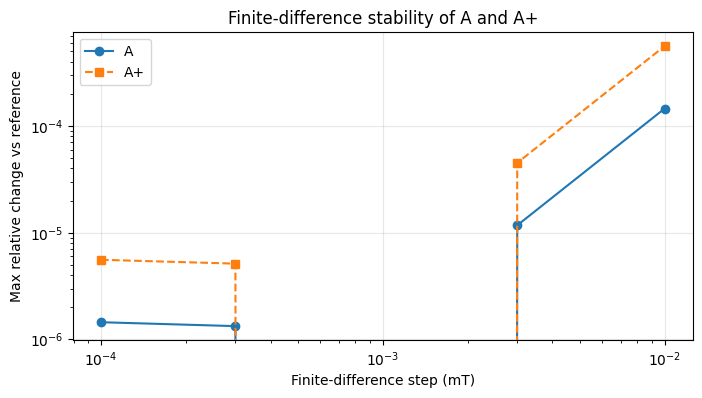

In [13]:
steps = np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2], dtype=float)

A_steps = []
A_plus_steps = []

for step in steps:
    A_tmp = np.zeros((4, 3), dtype=float)

    for j in range(3):
        B_plus = B0 + step * unit_vectors[j]
        B_minus = B0 - step * unit_vectors[j]

        f_left_plus = []
        f_left_minus = []

        for axis in axes_order:
            ex = LOCAL_FRAMES[axis]["ex"]
            ey = LOCAL_FRAMES[axis]["ey"]
            ez = LOCAL_FRAMES[axis]["ez"]

            Bx_loc_p = np.dot(B_plus, ex)
            By_loc_p = np.dot(B_plus, ey)
            Bz_loc_p = np.dot(B_plus, ez)
            H_plus = (D_fit_mhz + Mz_map[axis]) * Sz2 + GAMMA_E_MHZ_PER_MT * (Bx_loc_p * Sx + By_loc_p * Sy + Bz_loc_p * Sz)
            evals_plus = np.sort(np.real(np.linalg.eigvalsh(H_plus)))
            f_left_plus.append(evals_plus[1] - evals_plus[0])

            Bx_loc_m = np.dot(B_minus, ex)
            By_loc_m = np.dot(B_minus, ey)
            Bz_loc_m = np.dot(B_minus, ez)
            H_minus = (D_fit_mhz + Mz_map[axis]) * Sz2 + GAMMA_E_MHZ_PER_MT * (Bx_loc_m * Sx + By_loc_m * Sy + Bz_loc_m * Sz)
            evals_minus = np.sort(np.real(np.linalg.eigvalsh(H_minus)))
            f_left_minus.append(evals_minus[1] - evals_minus[0])

        A_tmp[:, j] = (np.array(f_left_plus) - np.array(f_left_minus)) / (2.0 * step)

    A_steps.append(A_tmp)
    A_plus_steps.append(np.linalg.pinv(A_tmp))

A_steps = np.array(A_steps)
A_plus_steps = np.array(A_plus_steps)

step_stability_rows = []
A_ref = A_steps[2]         # step = 1e-3 mT
Aplus_ref = A_plus_steps[2]

for k, step in enumerate(steps):
    rel_A = np.max(np.abs((A_steps[k] - A_ref) / (A_ref + 1e-15)))
    rel_Aplus = np.max(np.abs((A_plus_steps[k] - Aplus_ref) / (Aplus_ref + 1e-15)))

    step_stability_rows.append({
        "step_mT": step,
        "max_rel_change_A_vs_ref": rel_A,
        "max_rel_change_Aplus_vs_ref": rel_Aplus,
    })

step_stability_df = pd.DataFrame(step_stability_rows)
display(step_stability_df)
plt.figure(figsize=(8, 4))
plt.loglog(step_stability_df["step_mT"], step_stability_df["max_rel_change_A_vs_ref"], "o-", label="A")
plt.loglog(step_stability_df["step_mT"], step_stability_df["max_rel_change_Aplus_vs_ref"], "s--", label="A+")
plt.xlabel("Finite-difference step (mT)")
plt.ylabel("Max relative change vs reference")
plt.title("Finite-difference stability of A and A+")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [14]:
# Synthetic perturbation in the same working frame
dB_test = np.array([0.002, -0.001, 0.0015], dtype=float)  # mT

dnu_test = A @ dB_test
dB_recon = A_plus @ dnu_test

roundtrip_df = pd.DataFrame({
    "component": ["Bx", "By", "Bz"],
    "dB_true_mT": dB_test,
    "dB_recon_mT": dB_recon,
    "error_uT": 1e3 * (dB_recon - dB_test),
})

display(roundtrip_df)

,component,dB_true_mT,dB_recon_mT,error_uT
0,Bx,0.0020,0.0020,8.673617e-16
1,By,-0.0010,-0.0010,-6.505213e-16
2,Bz,0.0015,0.0015,1.301043e-15


In [15]:
A_rows = []
for i, ax in enumerate(axes_order):
    for j, comp in enumerate(["Bx", "By", "Bz"]):
        A_rows.append({
            "group": "A_matrix",
            "row": ax,
            "col": comp,
            "value": float(A[i, j]),
            "units": "MHz_per_mT",
        })

Aplus_rows = []
for i, comp in enumerate(["Bx", "By", "Bz"]):
    for j, ax in enumerate(axes_order):
        Aplus_rows.append({
            "group": "A_plus",
            "row": comp,
            "col": ax,
            "value": float(A_plus[i, j]),
            "units": "mT_per_MHz",
        })

meta_rows = [
    {"group": "meta", "row": "tracked_branch", "col": "-", "value": "lower_frequency_transitions_d1_d2_d3_d4", "units": "-"},
    {"group": "meta", "row": "frame", "col": "-", "value": "crystal_attached_working_frame", "units": "-"},
    {"group": "meta", "row": "dB_step_mT", "col": "-", "value": float(dB_step_mT), "units": "mT"},
    {"group": "meta", "row": "Bx0_mT", "col": "-", "value": float(Bx0), "units": "mT"},
    {"group": "meta", "row": "By0_mT", "col": "-", "value": float(By0), "units": "mT"},
    {"group": "meta", "row": "Bz0_mT", "col": "-", "value": float(Bz0), "units": "mT"},
    {"group": "meta", "row": "D_fit_MHz", "col": "-", "value": float(D_fit_mhz), "units": "MHz"},
    {"group": "meta", "row": "Mz_d1_MHz", "col": "-", "value": float(Mz_d1), "units": "MHz"},
    {"group": "meta", "row": "Mz_d2_MHz", "col": "-", "value": float(Mz_d2), "units": "MHz"},
    {"group": "meta", "row": "Mz_d3_MHz", "col": "-", "value": float(Mz_d3), "units": "MHz"},
    {"group": "meta", "row": "Mz_d4_MHz", "col": "-", "value": float(Mz_d4), "units": "MHz"},
]

A_results_df = pd.DataFrame(A_rows + Aplus_rows + meta_rows)
A_results_df.to_csv("A_results.csv", index=False)

np.savez(
    "A_bundle.npz",
    A=A,
    A_plus=A_plus,
    B0=B0,
    D_fit_mhz=D_fit_mhz,
    Mz=np.array([Mz_d1, Mz_d2, Mz_d3, Mz_d4], dtype=float),
    axes_order=np.array(axes_order, dtype=object),
    tracked_branch="lower_frequency_transitions",
    dB_step_mT=dB_step_mT,
)

print("Saved:")
print("  A_results.csv")
print("  A_bundle.npz")

Saved:
  A_results.csv
  A_bundle.npz
